0.54


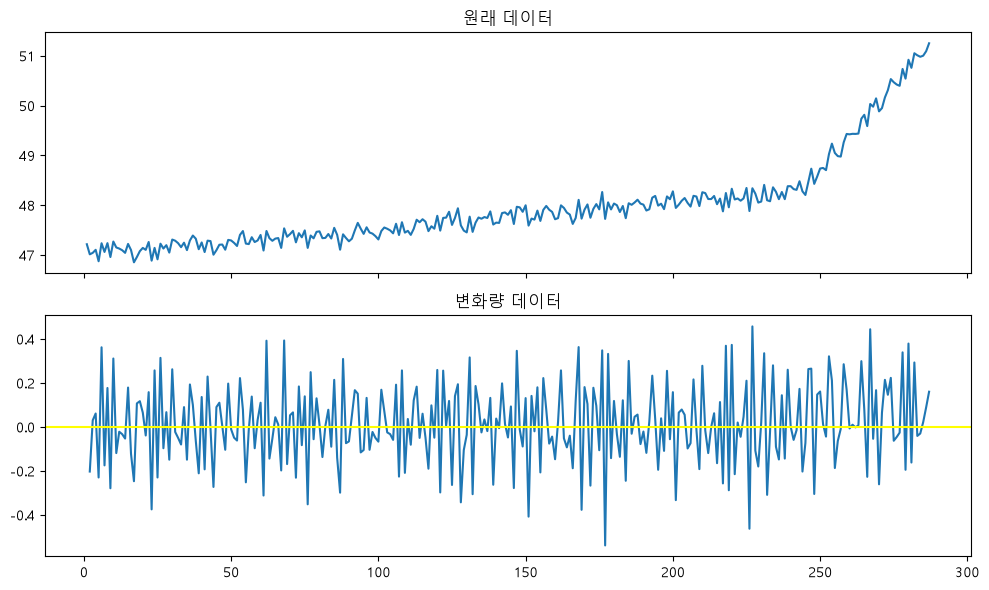

In [1]:
# 실습 1. 변화량으로 급변 탐지하기

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('.venv/21_cmapss_fd001_sample.csv')

# print(df.shape) # (1031, 10)

engine2 = df[df['unit_nr'] == 2]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)


ax1.set_title('원래 데이터')
ax1.plot(engine2['time_cycles'], engine2['s_11'])

ax2.set_title('변화량 데이터')
diff = engine2['s_11'].diff()
ax2.plot(engine2['time_cycles'], diff)

# 0 기준선 긋기

ax2.axhline(0, color='yellow')

# 최대 급변량 확인
print(diff.abs().max().round(2))

plt.tight_layout()
plt.show()

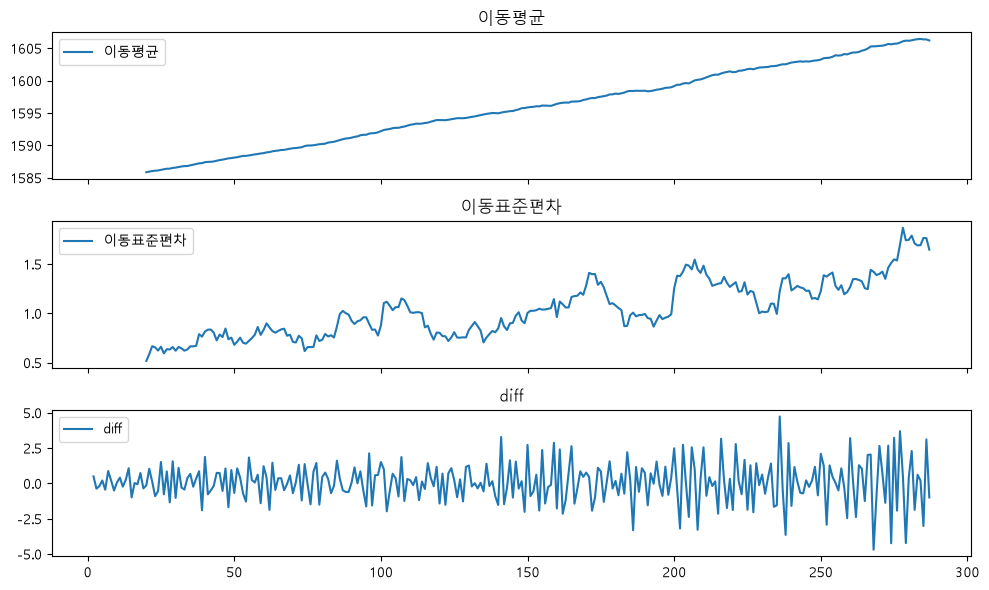

In [2]:
# 실습 2. 추세 변동성 변화량 종합 관찰

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(10, 6), sharex=True
)

# 1. 이동평균
ax1.set_title('이동평균')
ma = engine2['s_3'].rolling(20).mean()

# ax1.plot(engine2['time_cycles'], engine2['s_3'], label='원본')
ax1.plot(engine2['time_cycles'], ma, label='이동평균')
ax1.legend()


# 2. 이동표준편차
ax2.set_title('이동표준편차')
std = engine2['s_3'].rolling(20).std()

# ax2.plot(engine2['time_cycles'], engine2['s_3'], label='원본')
ax2.plot(engine2['time_cycles'], std, label='이동표준편차')
ax2.legend()


# 3. 변화량
ax3.set_title('diff')
diff = engine2['s_3'].diff()

# ax3.plot(engine2['time_cycles'], engine2['s_3'], label='원본')
ax3.plot(engine2['time_cycles'], diff, label='diff')
ax3.legend()


plt.tight_layout()
plt.show()

(192, 6)


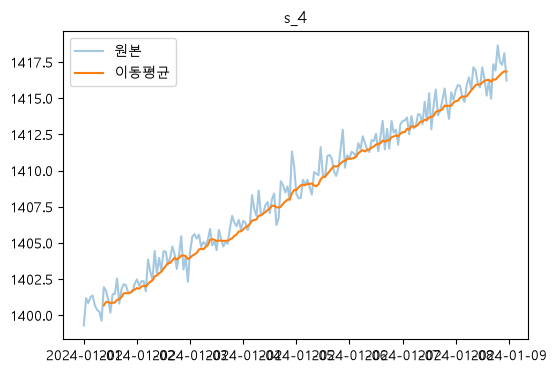

In [3]:
# 실습 3. 시간 단위 추세 보기

df = pd.read_csv('.venv/21_engine1_timestamp_sample.csv')
print(df.shape)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

plt.figure(figsize=(6, 4))
plt.title('s_4')
plt.plot(df.index, df['s_4'], label='원본', alpha=0.4)
plt.plot(df.index, df['s_4'].rolling(10).mean(), label='이동평균')
plt.legend()

plt.show()